# Experiment 04 — Effect of Projection Count $r$ on LSHFed Distance Fidelity and Cost

## Objective

This experiment studies how the number of random hyperplanes $r$ affects three properties in LSHFed:
1. Distance fidelity: correlation, i.e. how LSH Hamming distance and full Euclidean distance are associated with each other when calculating the distance between model parameter updates.
2. Decision fidelity: winner agreement, i.e., whether Hamming distance and Euclidean distance select the same aggregation group (AG) within each round.
3. Cost: hash-generation time, Hamming-comparison time, and hash size as $r$ increases.

This helps investigate the fidelity-cost tradeoff at different value of $r$.

To ensure that the controlled variable $r$ is solely responsible for the differences in our observed outcomes, and that the effects of varying $r$ are not confounded with varying federated learning trajectories, this notebook uses one fixed FL-trajectory.

By using $r=5$ as a baseline, a fixed train-aggregate-filter-update federated learning trajectory is generated, and the benchmark-candidate pairs of every FL round are recorded and frozen. All values of $r$ are then evaluated on this frozen trajectory.

## Experimental design

- Dataset: CIFAR-10
- Training subset: 10,000 randomly selected examples
- Local trainers (LTs): 5
- Aggregation groups (AGs): 2
- Grouping: round-robin, yielding AG 0 = LTs `[0, 2, 4]` and AG 1 = LTs `[1, 3]`
- Local epochs per round: 1
- Federated rounds: 8
- Baseline trajectory selector: LSH Hamming distance with $r=5$
- Tested projection counts: $r \in \{1,2,4,5,8,16,32,64,128,256\}$

Round 0 has no previous benchmark. AG 0 is therefore chosen deterministically only to initialize the controlled trajectory.

From round 1 onward, both current AG updates are compared with the previous selected AG update, and the lower-Hamming candidate under baseline $r=5$ becomes the next benchmark and global state.

### What is federated versus what is compared

The complete trained model state is federated for the selected AG so that BatchNorm running statistics evolve coherently across rounds. However, LSH and Euclidean distances are computed only on trainable parameter updates, matching notebook 03.

## 1. Imports, paths, and reproducibility

The notebook is self-contained. It doesn't clone the LSHFed repo or depend on Google Drive. CIFAR-10 is downloaded automatically by `torchvision`, and all generated outputs use paths relative to the notebook's working directory.

The random hyperplanes are still drawn from the authors' standard-normal distribution. Explicit seeds are added only to make the experiment reproducible.

In [1]:
from pathlib import Path
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in (DATA_DIR, RESULTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Improve reproducibility where supported. Exact bitwise identity is not
# guaranteed across all CUDA hardware/software combinations.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

R_VALUES = [1, 2, 4, 5, 8, 16, 32, 64, 128, 256]
BASELINE_R = 5
MAX_R = max(R_VALUES)
NUM_ROUNDS = 8
NUM_LTS = 5
NUM_AGS = 2

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Working directory:", Path.cwd().resolve())
print("r values:", R_VALUES)

Device: cuda
PyTorch: 2.11.0+cu128
Working directory: /content
r values: [1, 2, 4, 5, 8, 16, 32, 64, 128, 256]


## 2. CIFAR-10 subset and LT partitioning

A deterministic 10,000-example subset is sampled from the CIFAR-10 training set and then split evenly across five LTs. This is a random/IID-style partition baseline, not a Dirichlet non-IID setting.

Each LT receives its own seeded `DataLoader` generator so that local minibatch shuffling does not depend on hidden notebook RNG state.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

TRAIN_SAMPLES = 10_000
BATCH_SIZE = 32

rng = np.random.default_rng(SEED)
subset_indices = rng.choice(
    len(train_dataset),
    size=TRAIN_SAMPLES,
    replace=False,
)

# Shuffle the selected indices once, then split them evenly across LTs.
rng = np.random.default_rng(SEED)
rng.shuffle(subset_indices)
lt_indices = np.array_split(subset_indices, NUM_LTS)

lt_loaders = []
for lt_id, indices in enumerate(lt_indices):
    lt_dataset = Subset(train_dataset, indices.tolist())
    loader_generator = torch.Generator().manual_seed(SEED + lt_id)
    loader = DataLoader(
        lt_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=loader_generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    lt_loaders.append(loader)
    print(f"LT {lt_id}: {len(lt_dataset)} samples, {len(loader)} batches")

100%|██████████| 170M/170M [36:44<00:00, 77.3kB/s]


LT 0: 2000 samples, 63 batches
LT 1: 2000 samples, 63 batches
LT 2: 2000 samples, 63 batches
LT 3: 2000 samples, 63 batches
LT 4: 2000 samples, 63 batches


## 3. ResNet9-style CIFAR-10 model

The model matches the ResNet9-style `CustomModel` used by the authors (and replicated in the previous notebook 03 as well).

In [3]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)


class CustomModel(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(
            conv_block(128, 128),
            conv_block(128, 128),
        )
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(
            conv_block(512, 512),
            conv_block(512, 512),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        return self.classifier(out)


model_for_check = CustomModel()
print("Total parameters:", sum(p.numel() for p in model_for_check.parameters()))

Total parameters: 6575370


## 4. Complete-state federation and trainable-parameter updates

Each LT starts from the complete current global state. After local training it returns:

- a dictionary of trainable parameter deltas (`after - before`) for distance analysis; and
- its complete resulting state, including BatchNorm buffers.

For an AG (aggregator), the trainable updates that it receives from its LTs (local trainers) are averaged element-wise. Floating-point buffers such as BatchNorm `running_mean` and `running_var` are also averaged. Overall, the complete model state is aggregated so that the selected AG can become the next coherent global model state.

In [4]:
def clone_model_state(model):
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def compute_parameter_update(before_state, after_model):
    return {
        name: (param.detach().cpu() - before_state[name]).clone()
        for name, param in after_model.named_parameters()
    }


def average_updates(updates):
    if not updates:
        raise ValueError("No updates supplied.")
    return {
        name: torch.stack([update[name] for update in updates], dim=0).mean(dim=0)
        for name in updates[0]
    }


def average_complete_states(states):
    if not states:
        raise ValueError("No states supplied.")

    averaged = {}
    for name in states[0]:
        values = [state[name] for state in states]

        if torch.is_floating_point(values[0]):
            averaged[name] = torch.stack(values, dim=0).mean(dim=0)
        elif name.endswith("num_batches_tracked"):
            averaged[name] = torch.stack(values, dim=0).max(dim=0).values
        else:
            averaged[name] = values[0].clone()

    return averaged

## 5. Local training

Each LT performs one local epoch with SGD. The returned elapsed time only involves local tranining and is not part of the LSH runtime measurements in the later $r$ sweep.

In [5]:
LOCAL_EPOCHS = 1
LOCAL_LR = 0.01
MOMENTUM = 0.9


def train_one_lt(global_state, loader, device=DEVICE):
    model = CustomModel().to(device)
    model.load_state_dict(global_state)
    model.train()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LOCAL_LR,
        momentum=MOMENTUM,
    )

    start = time.perf_counter()

    for _ in range(LOCAL_EPOCHS):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            loss = F.cross_entropy(model(images), labels)
            loss.backward()
            optimizer.step()

    elapsed = time.perf_counter() - start

    parameter_update = compute_parameter_update(global_state, model)
    complete_state = clone_model_state(model)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return parameter_update, complete_state, elapsed

## 6. LSHFed-compatible random-hyperplane hashing

The hashing functions below reproduce the logic of the authors' released `utils.py::_flatten_to_2d`, `lsh.py::LSH`, and `lsh.py::LSH_cmp`:

- 1D tensors are reshaped to `(-1, 1)`;
- 2D tensors are left unchanged;
- higher-dimensional tensors are reshaped to `(size(0), -1)`;
- for every random vector, the code computes `torch.mv(grad_2d.t(), rand_vec)`;
- bits are produced by the strict threshold `dots > 0`;
- Hamming distance counts unequal flattened bits.

Every smaller $r$ uses a prefix of the same $r=256$ master bank for its vector dimension, similar to the previous three experiments, as we do not want to introduce unnecessary variability by generating a new bank of vectors at every $r$.

Because runtime efficiency is an outcome that we intend to observe, the code intentionally retains the authors' per-vector `torch.mv` loop rather than replacing it with a faster vectorized matrix multiplication.

In [6]:
def flatten_to_2d_exact(tensor):
    """Faithful to LSHFed utils.py::_flatten_to_2d."""
    if tensor.dim() == 1:
        return tensor.view(-1, 1)
    if tensor.dim() == 2:
        return tensor
    return tensor.view(tensor.size(0), -1)


# Determine every row dimension needed by trainable parameters.
VECTOR_LENGTHS = sorted({
    flatten_to_2d_exact(param.detach().cpu()).size(0)
    for _, param in CustomModel().named_parameters()
})


def build_master_projection_banks(vector_lengths, max_r, seed=SEED):
    """
    Draw standard-normal random vectors, matching the authors' distribution.
    A separate deterministic generator is used for each vector dimension.
    """
    banks = {}
    for vector_length in vector_lengths:
        generator = torch.Generator(device="cpu")
        generator.manual_seed(seed + vector_length)
        banks[vector_length] = [
            torch.randn(vector_length, generator=generator)
            for _ in range(max_r)
        ]
    return banks


MASTER_PROJECTION_BANKS = build_master_projection_banks(
    VECTOR_LENGTHS,
    MAX_R,
)


def lsh_tensor_exact(tensor, r):
    """Faithful hashing logic from the authors' lsh.py, with in-memory banks."""
    grad_2d = flatten_to_2d_exact(tensor.detach().to("cpu"))
    random_vectors = MASTER_PROJECTION_BANKS[grad_2d.size(0)][:r]

    hashes = []
    for rand_vec in random_vectors:
        dots = torch.mv(grad_2d.t(), rand_vec)
        hashes.append((dots > 0).int().tolist())

    return hashes


def lsh_cmp_exact(list1, list2):
    """Faithful comparison logic from the authors' lsh.py::LSH_cmp."""
    tensor1 = torch.tensor(list1)
    tensor2 = torch.tensor(list2)

    if tensor1.shape != tensor2.shape:
        raise ValueError("LSH cannot compare two tensors with different shapes")

    differences = torch.ne(tensor1.flatten(), tensor2.flatten())
    return int(torch.sum(differences).item())


def lsh_model(update_dict, r):
    """Hash every trainable parameter tensor separately, as advised by LSHFed."""
    return {
        name: lsh_tensor_exact(tensor.float(), r)
        for name, tensor in update_dict.items()
    }


def hamming_model(hash_a, hash_b):
    """Sum layer-wise LSH_cmp distances into one model-update Hamming distance."""
    return int(sum(
        lsh_cmp_exact(hash_a[name], hash_b[name])
        for name in hash_a
    ))


for vector_length in VECTOR_LENGTHS:
    assert len(MASTER_PROJECTION_BANKS[vector_length]) == MAX_R
    assert all(v.numel() == vector_length for v in MASTER_PROJECTION_BANKS[vector_length])

print("Required projection dimensions:", VECTOR_LENGTHS)
print("Nested master banks ready through r =", MAX_R)

Required projection dimensions: [10, 64, 128, 256, 512]
Nested master banks ready through r = 256


## 7. Euclidean reference distance

For two model parameter-update dictionaries $U$ and $V$, the reference Euclidean distance is the full L2 distance over all trainable parameters:

$$
 d_E(U,V)=\sqrt{\sum_l \|U_l-V_l\|^2}.
$$

This Euclidean distance is computed over every frozen candidate–benchmark pair, in order to select which current round candidate aggregator is closest in model parameter update to the previous round's global benchmark model.

In [7]:
def euclidean_model(update_a, update_b):
    total_sq = 0.0
    for name in update_a:
        diff = update_a[name].float() - update_b[name].float()
        total_sq += torch.sum(diff * diff).item()
    return float(np.sqrt(total_sq))

## 8. LT-to-AG grouping and aggregation

LTs (local trainers) are assigned to AGs (aggregators) round-robin. All LTs receive the same number of training examples.

In [8]:
LT_IDS = list(range(NUM_LTS))
AG_IDS = list(range(NUM_AGS))


def group_lts_to_ags(lt_ids, ag_ids):
    groups = {ag_id: [] for ag_id in ag_ids}
    for index, lt_id in enumerate(lt_ids):
        groups[ag_ids[index % len(ag_ids)]].append(lt_id)
    return groups


def aggregate_lt_updates(lt_updates, members):
    return average_updates([lt_updates[lt_id] for lt_id in members])


def aggregate_lt_states(lt_states, members):
    return average_complete_states([lt_states[lt_id] for lt_id in members])


GROUPS = group_lts_to_ags(LT_IDS, AG_IDS)
for ag_id, members in GROUPS.items():
    print(f"AG {ag_id}: LT {members}")

AG 0: LT [0, 2, 4]
AG 1: LT [1, 3]


## 9. Generate and freeze one baseline-$r=5$ federated trajectory

This is the main step which generates one fixed federated learning trajectory with eight rounds of federation, where local training, aggregation, best candidate aggregator selection and global model update happen iteratively.

For round 0, AG 0 is selected deterministically as the initial benchmark. From round 1 onward:

1. every LT (local trainer) trains from the same current global state;
2. LT updates/states are aggregated within each corresponding AG (aggregator);
3. each current AG update is compared with the previous selected AG update using baseline $r=5$ Hamming distance;
4. both candidate-versus-benchmark observations (i.e. benchmark-vs-AG0 and benchmark-vs-AG1) are frozen;
5. the lower-Hamming-distant AG becomes the next benchmark; and
6. that winning AG's complete aggregated state becomes the next global state.

The frozen structure stores one benchmark update and both candidate updates for every comparison round.

In [9]:
global_model = CustomModel().to(DEVICE)
global_state = clone_model_state(global_model)

previous_benchmark_update = None
previous_benchmark_ag = None

# Seven comparison rounds are expected for eight total rounds.
frozen_rounds = []

print("=" * 70)
print(f"Generating fixed trajectory with baseline r = {BASELINE_R}")
print("=" * 70)

for round_id in range(NUM_ROUNDS):
    print(f"\n========== TRAJECTORY ROUND {round_id} ==========")

    # 1. Local training.
    lt_updates = {}
    lt_states = {}

    for lt_id in LT_IDS:
        print(f"  Training LT {lt_id}...", end=" ", flush=True)
        update, state, elapsed = train_one_lt(
            global_state,
            lt_loaders[lt_id],
            DEVICE,
        )
        lt_updates[lt_id] = update
        lt_states[lt_id] = state
        print(f"{elapsed:.2f}s")

    # 2. AG aggregation.
    ag_updates = {
        ag_id: aggregate_lt_updates(lt_updates, members)
        for ag_id, members in GROUPS.items()
    }
    ag_states = {
        ag_id: aggregate_lt_states(lt_states, members)
        for ag_id, members in GROUPS.items()
    }

    # 3. Round 0 initializes the benchmark deterministically.
    if previous_benchmark_update is None:
        winner_ag = AG_IDS[0]
        previous_benchmark_update = copy.deepcopy(ag_updates[winner_ag])
        previous_benchmark_ag = winner_ag
        global_state = copy.deepcopy(ag_states[winner_ag])
        print(f"  Initial benchmark selected deterministically: AG {winner_ag}")
        continue

    # 4. Baseline-r hashes and reference distances.
    benchmark_hash = lsh_model(previous_benchmark_update, BASELINE_R)
    current_hashes = {
        ag_id: lsh_model(ag_updates[ag_id], BASELINE_R)
        for ag_id in AG_IDS
    }

    candidate_metrics = {}
    for ag_id in AG_IDS:
        candidate_metrics[ag_id] = {
            "hamming": hamming_model(current_hashes[ag_id], benchmark_hash),
            "euclidean": euclidean_model(
                ag_updates[ag_id],
                previous_benchmark_update,
            ),
        }

    # 5. Freeze exactly this round's benchmark and both candidates.
    frozen_rounds.append({
        "round": round_id,
        "benchmark_ag": previous_benchmark_ag,
        "benchmark_update": {
            name: tensor.clone()
            for name, tensor in previous_benchmark_update.items()
        },
        "candidate_updates": {
            ag_id: {
                name: tensor.clone()
                for name, tensor in ag_updates[ag_id].items()
            }
            for ag_id in AG_IDS
        },
        # Euclidean distance is independent of r, so preserve it once here.
        "euclidean_distances": {
            ag_id: candidate_metrics[ag_id]["euclidean"]
            for ag_id in AG_IDS
        },
    })

    # 6. Select the next benchmark using baseline r=5 Hamming distance.
    winner_ag = min(
        AG_IDS,
        key=lambda ag_id: candidate_metrics[ag_id]["hamming"],
    )

    print(f"  Previous benchmark: AG {previous_benchmark_ag}")
    for ag_id in AG_IDS:
        metrics = candidate_metrics[ag_id]
        print(
            f"  AG {ag_id} | "
            f"Hamming={metrics['hamming']} | "
            f"Euclidean={metrics['euclidean']:.6f}"
        )
    print(f"  Baseline-r winner: AG {winner_ag}")

    # 7. Advance both the benchmark update and coherent global model state.
    previous_benchmark_update = copy.deepcopy(ag_updates[winner_ag])
    previous_benchmark_ag = winner_ag
    global_state = copy.deepcopy(ag_states[winner_ag])


expected_rounds = NUM_ROUNDS - 1
expected_pairs = expected_rounds * NUM_AGS
actual_pairs = len(frozen_rounds) * NUM_AGS

assert len(frozen_rounds) == expected_rounds
assert actual_pairs == expected_pairs

print("\n" + "=" * 70)
print("FIXED TRAJECTORY COMPLETE")
print("=" * 70)
print("Frozen comparison rounds:", len(frozen_rounds))
print("Frozen candidate-vs-benchmark observations:", actual_pairs)

Generating fixed trajectory with baseline r = 5

========== TRAJECTORY ROUND 0 ==========
  Training LT 0... 2.27s
  Training LT 1... 1.02s
  Training LT 2... 1.02s
  Training LT 3... 1.06s
  Training LT 4... 1.14s
  Initial benchmark selected deterministically: AG 0

========== TRAJECTORY ROUND 1 ==========
  Training LT 0... 1.02s
  Training LT 1... 1.04s
  Training LT 2... 1.02s
  Training LT 3... 1.02s
  Training LT 4... 1.02s
  Previous benchmark: AG 0
  AG 0 | Hamming=40589 | Euclidean=9.005768
  AG 1 | Hamming=42590 | Euclidean=9.414358
  Baseline-r winner: AG 0

========== TRAJECTORY ROUND 2 ==========
  Training LT 0... 1.03s
  Training LT 1... 1.03s
  Training LT 2... 1.03s
  Training LT 3... 1.10s
  Training LT 4... 1.11s
  Previous benchmark: AG 0
  AG 0 | Hamming=37919 | Euclidean=3.857728
  AG 1 | Hamming=41972 | Euclidean=4.093187
  Baseline-r winner: AG 0

========== TRAJECTORY ROUND 3 ==========
  Training LT 0... 1.03s
  Training LT 1... 1.03s
  Training LT 2... 1.03s

## 10. Inspect the frozen comparison population

The expected population is $(8-1) * 2 = 14$ candidate-versus-benchmark observations. The metadata table shows the Euclidean distance between the candidates and the benchmark for every FL round.

In [10]:
frozen_metadata_rows = []
for frozen in frozen_rounds:
    for ag_id in AG_IDS:
        frozen_metadata_rows.append({
            "round": frozen["round"],
            "benchmark_ag": frozen["benchmark_ag"],
            "candidate_ag": ag_id,
            "euclidean_distance": frozen["euclidean_distances"][ag_id],
        })

frozen_metadata_df = pd.DataFrame(frozen_metadata_rows)
display(frozen_metadata_df)

,round,benchmark_ag,candidate_ag,euclidean_distance
0,1,0,0,9.005768
1,1,0,1,9.414358
2,2,0,0,3.857728
3,2,0,1,4.093187
4,3,0,0,3.043980
5,3,0,1,3.342457
6,4,0,0,2.701081
7,4,0,1,2.948991
8,5,0,0,2.612857
9,5,0,1,2.743014


## 11. Hash-size calculation

For a flattened trainable tensor with shape `(rows, columns)`, each random hyperplane contributes one bit per column. Therefore a complete model-update hash contains

$$
	\text{hash bits}(r) = r\sum_L	\text{columns}_L.
$$

The model structure is fixed, so this quantity is computed once per $r$ rather than repeatedly for every observation.

The number of $rows$ dictates the dimension of the projection hyperplane.

$Columns$ shows how many columns have to be separately projected and hashed. The value of $r$ dictates the number of hashed bits used to represent one column. Together, they control the total length of a hashed string used to represent an entire parameter update tensor.

In [11]:
def model_hash_bits_for_r(model, r):
    columns_per_projection = 0
    for _, parameter in model.named_parameters():
        flattened = flatten_to_2d_exact(parameter.detach().cpu())
        columns_per_projection += flattened.size(1)
    return int(r * columns_per_projection)


HASH_BITS_BY_R = {
    r: model_hash_bits_for_r(CustomModel(), r)
    for r in R_VALUES
}

for r in R_VALUES:
    print(f"r={r:>3}: {HASH_BITS_BY_R[r]:,} bits ({HASH_BITS_BY_R[r] / 8:,.1f} bytes)")

r=  1: 16,116 bits (2,014.5 bytes)
r=  2: 32,232 bits (4,029.0 bytes)
r=  4: 64,464 bits (8,058.0 bytes)
r=  5: 80,580 bits (10,072.5 bytes)
r=  8: 128,928 bits (16,116.0 bytes)
r= 16: 257,856 bits (32,232.0 bytes)
r= 32: 515,712 bits (64,464.0 bytes)
r= 64: 1,031,424 bits (128,928.0 bytes)
r=128: 2,062,848 bits (257,856.0 bytes)
r=256: 4,125,696 bits (515,712.0 bytes)


## 12. Controlled $r$ sweep

Every tested $r$ is evaluated on the same frozen updates.

For each candidate-versus-benchmark observation, the notebook records:

- Hamming distance for every value of $r$;
- the precomputed Euclidean reference distance;
- hash-generation time for hashing both candidate and benchmark;
- Hamming-comparison time; and
- total hash size.

The code iteratively processes all values of $r$. For each value, $r$ hyperplanes are chosen from the projection bank. The hyperplanes are used to project the frozen model update tensors into hashed binary strings. The Hamming distance is calculated between benchmark-vs-AG0 and benchmark-vs-AG1 LSH hashings.

In [12]:
all_observation_rows = []
all_winner_rows = []
summary_rows = []

for r in R_VALUES:
    print("\n" + "=" * 70)
    print(f"RUNNING CONTROLLED SWEEP: r = {r}")
    print("=" * 70)

    r_rows = []

    for pair_id, metadata_row in enumerate(frozen_metadata_rows):
        round_id = metadata_row["round"]
        candidate_ag = metadata_row["candidate_ag"]

        frozen = next(item for item in frozen_rounds if item["round"] == round_id)
        candidate_update = frozen["candidate_updates"][candidate_ag]
        benchmark_update = frozen["benchmark_update"]

        # Hash generation is CPU-based, matching the authors' LSH implementation.
        t0 = time.perf_counter()
        candidate_hash = lsh_model(candidate_update, r)
        benchmark_hash = lsh_model(benchmark_update, r)
        hash_generation_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        hamming_distance = hamming_model(candidate_hash, benchmark_hash)
        hamming_time = time.perf_counter() - t0

        row = {
            "r": r,
            "pair_id": pair_id,
            "round": round_id,
            "benchmark_ag": metadata_row["benchmark_ag"],
            "candidate_ag": candidate_ag,
            "hamming_distance": hamming_distance,
            "euclidean_distance": metadata_row["euclidean_distance"],
            "hash_generation_time_sec": hash_generation_time,
            "hamming_time_sec": hamming_time,
            "hash_bits": HASH_BITS_BY_R[r],
        }
        r_rows.append(row)
        all_observation_rows.append(row)

    r_df = pd.DataFrame(r_rows)

    pearson_r, pearson_p = pearsonr(
        r_df["euclidean_distance"],
        r_df["hamming_distance"],
    )
    spearman_r, spearman_p = spearmanr(
        r_df["euclidean_distance"],
        r_df["hamming_distance"],
    )

    winner_rows_for_r = []
    for round_id, group in r_df.groupby("round"):
        hamming_winner = group.loc[
            group["hamming_distance"].idxmin(),
            "candidate_ag",
        ]
        euclidean_winner = group.loc[
            group["euclidean_distance"].idxmin(),
            "candidate_ag",
        ]

        winner_row = {
            "r": r,
            "round": round_id,
            "hamming_winner": int(hamming_winner),
            "euclidean_winner": int(euclidean_winner),
            "same_winner": bool(hamming_winner == euclidean_winner),
        }
        winner_rows_for_r.append(winner_row)
        all_winner_rows.append(winner_row)

    winner_df = pd.DataFrame(winner_rows_for_r)
    winner_agreement = float(winner_df["same_winner"].mean())

    avg_hash_generation = float(r_df["hash_generation_time_sec"].mean())
    avg_hamming = float(r_df["hamming_time_sec"].mean())

    summary_rows.append({
        "r": r,
        "pearson": pearson_r,
        "pearson_p": pearson_p,
        "spearman": spearman_r,
        "spearman_p": spearman_p,
        "winner_agreement": winner_agreement,
        "avg_hash_generation_time_sec": avg_hash_generation,
        "avg_hamming_time_sec": avg_hamming,
        "avg_lsh_total_time_sec": avg_hash_generation + avg_hamming,
        "hash_bits": HASH_BITS_BY_R[r],
        "hash_bytes": HASH_BITS_BY_R[r] / 8,
    })

    print(f"Pearson:          {pearson_r:.6f} (p={pearson_p:.6g})")
    print(f"Spearman:         {spearman_r:.6f} (p={spearman_p:.6g})")
    print(f"Winner agreement: {winner_agreement:.4f}")
    print(f"Avg hash gen.:    {avg_hash_generation:.6f}s")
    print(f"Avg Hamming:      {avg_hamming:.6f}s")
    print(f"Hash size:        {HASH_BITS_BY_R[r]:,} bits")


observations_df = pd.DataFrame(all_observation_rows)
winner_agreement_df = pd.DataFrame(all_winner_rows)
summary_df = pd.DataFrame(summary_rows)

display(summary_df)


RUNNING CONTROLLED SWEEP: r = 1
Pearson:          0.031102 (p=0.915942)
Spearman:         0.072527 (p=0.805376)
Winner agreement: 0.8571
Avg hash gen.:    0.007828s
Avg Hamming:      0.006086s
Hash size:        16,116 bits

RUNNING CONTROLLED SWEEP: r = 2
Pearson:          0.295128 (p=0.305663)
Spearman:         0.560440 (p=0.0371045)
Winner agreement: 0.8571
Avg hash gen.:    0.013471s
Avg Hamming:      0.011012s
Hash size:        32,232 bits

RUNNING CONTROLLED SWEEP: r = 4
Pearson:          0.479672 (p=0.0826182)
Spearman:         0.389011 (p=0.169217)
Winner agreement: 1.0000
Avg hash gen.:    0.022438s
Avg Hamming:      0.021927s
Hash size:        64,464 bits

RUNNING CONTROLLED SWEEP: r = 5
Pearson:          0.663081 (p=0.00974239)
Spearman:         0.397802 (p=0.158951)
Winner agreement: 1.0000
Avg hash gen.:    0.026152s
Avg Hamming:      0.026546s
Hash size:        80,580 bits

RUNNING CONTROLLED SWEEP: r = 8
Pearson:          0.542565 (p=0.045002)
Spearman:         0.331868 

,r,pearson,pearson_p,spearman,spearman_p,winner_agreement,avg_hash_generation_time_sec,avg_hamming_time_sec,avg_lsh_total_time_sec,hash_bits,hash_bytes
0,1,0.031102,0.915942,0.072527,0.805376,0.857143,0.007828,0.006086,0.013914,16116,2014.5
1,2,0.295128,0.305663,0.560440,0.037104,0.857143,0.013471,0.011012,0.024482,32232,4029.0
2,4,0.479672,0.082618,0.389011,0.169217,1.000000,0.022438,0.021927,0.044364,64464,8058.0
3,5,0.663081,0.009742,0.397802,0.158951,1.000000,0.026152,0.026546,0.052698,80580,10072.5
4,8,0.542565,0.045002,0.331868,0.246377,1.000000,0.040013,0.042412,0.082426,128928,16116.0
5,16,0.347373,0.223635,0.230769,0.427336,1.000000,0.073926,0.080516,0.154442,257856,32232.0
6,32,0.584366,0.028196,0.393407,0.164032,1.000000,0.140705,0.162708,0.303413,515712,64464.0
7,64,0.684520,0.006921,0.068132,0.816984,0.857143,0.308569,0.385348,0.693917,1031424,128928.0
8,128,0.709917,0.004449,0.076923,0.793806,0.714286,0.589397,0.758162,1.347560,2062848,257856.0
9,256,0.655979,0.010850,0.094505,0.747938,0.714286,1.178185,1.487972,2.666158,4125696,515712.0


In [15]:
# Clean summary tables

corr_table = summary_df[
    ["r", "pearson", "pearson_p", "spearman", "spearman_p", "winner_agreement"]
].rename(columns={
    "pearson": "pearson_corr",
    "pearson_p": "pearson_p_val",
    "spearman": "spearman_corr",
    "spearman_p": "spearman_p_val",
})

cost_table = summary_df[
    ["r", "avg_hash_generation_time_sec", "avg_hamming_time_sec",
     "avg_lsh_total_time_sec", "hash_bits", "hash_bytes"]
]

print("=== Distance & decision fidelity ===")
display(corr_table.round({
    "pearson_corr": 4,
    "pearson_p_val": 4,
    "spearman_corr": 4,
    "spearman_p_val": 4,
    "winner_agreement": 4,
}))

print("\n=== Cost ===")
display(cost_table.round({
    "avg_hash_generation_time_sec": 6,
    "avg_hamming_time_sec": 6,
    "avg_lsh_total_time_sec": 6,
    "hash_bytes": 1,
}))

=== Distance & decision fidelity ===


,r,pearson_corr,pearson_p_val,spearman_corr,spearman_p_val,winner_agreement
0,1,0.0311,0.9159,0.0725,0.8054,0.8571
1,2,0.2951,0.3057,0.5604,0.0371,0.8571
2,4,0.4797,0.0826,0.3890,0.1692,1.0000
3,5,0.6631,0.0097,0.3978,0.1590,1.0000
4,8,0.5426,0.0450,0.3319,0.2464,1.0000
5,16,0.3474,0.2236,0.2308,0.4273,1.0000
6,32,0.5844,0.0282,0.3934,0.1640,1.0000
7,64,0.6845,0.0069,0.0681,0.8170,0.8571
8,128,0.7099,0.0044,0.0769,0.7938,0.7143
9,256,0.6560,0.0108,0.0945,0.7479,0.7143



=== Cost ===


,r,avg_hash_generation_time_sec,avg_hamming_time_sec,avg_lsh_total_time_sec,hash_bits,hash_bytes
0,1,0.007828,0.006086,0.013914,16116,2014.5
1,2,0.013471,0.011012,0.024482,32232,4029.0
2,4,0.022438,0.021927,0.044364,64464,8058.0
3,5,0.026152,0.026546,0.052698,80580,10072.5
4,8,0.040013,0.042412,0.082426,128928,16116.0
5,16,0.073926,0.080516,0.154442,257856,32232.0
6,32,0.140705,0.162708,0.303413,515712,64464.0
7,64,0.308569,0.385348,0.693917,1031424,128928.0
8,128,0.589397,0.758162,1.347560,2062848,257856.0
9,256,1.178185,1.487972,2.666158,4125696,515712.0


## 13. Visualize the fidelity–decision–cost tradeoff

The plots separate the three outcomes:

- Pearson/Spearman: global Hamming-to-Euclidean distance correspondence across 14 observations;
- Winner agreement: within-round verifier decision (i.e. which aggregator gets chosen as next round's global model) correspondence across 7 rounds;
- Runtime / Hash size: computational cost of increasing $r$.


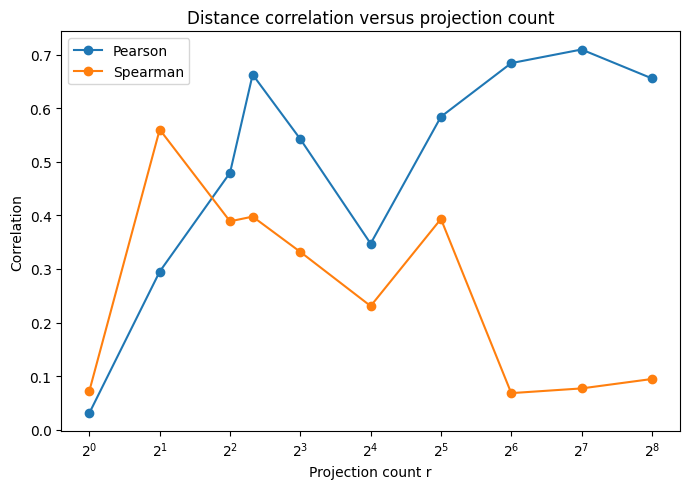

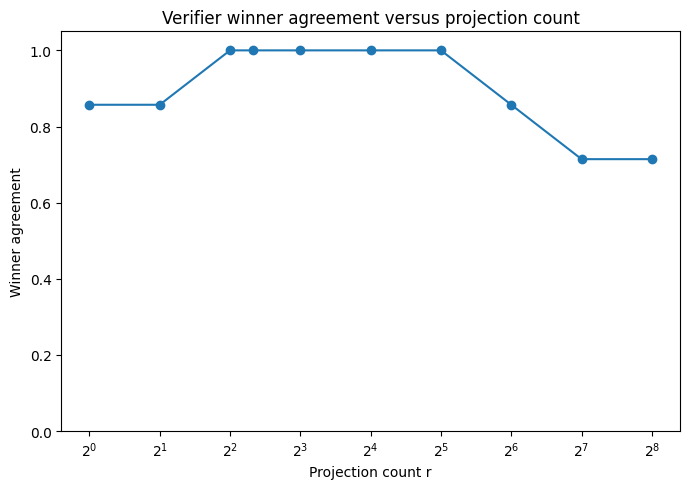

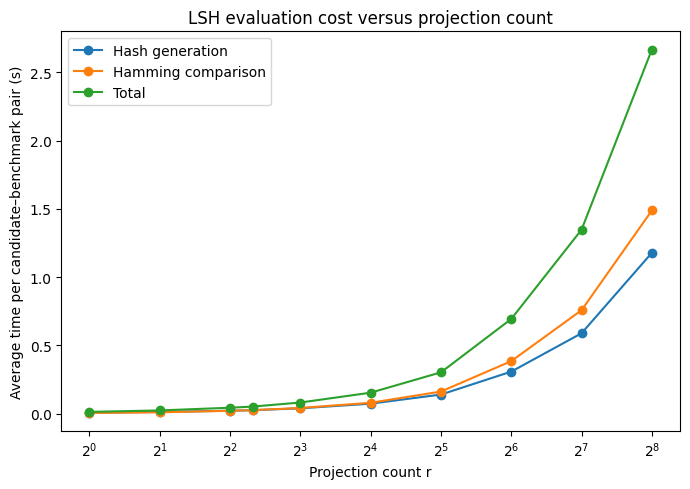

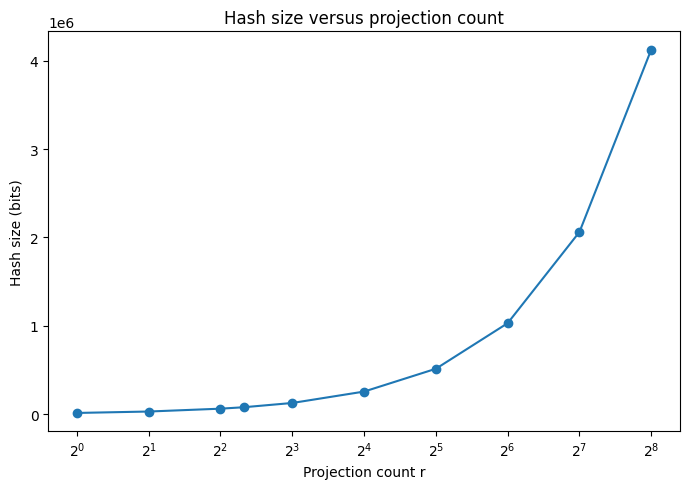

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(summary_df["r"], summary_df["pearson"], marker="o", label="Pearson")
plt.plot(summary_df["r"], summary_df["spearman"], marker="o", label="Spearman")
plt.xscale("log", base=2)
plt.xlabel("Projection count r")
plt.ylabel("Correlation")
plt.title("Distance correlation versus projection count")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(summary_df["r"], summary_df["winner_agreement"], marker="o")
plt.xscale("log", base=2)
plt.ylim(0, 1.05)
plt.xlabel("Projection count r")
plt.ylabel("Winner agreement")
plt.title("Verifier winner agreement versus projection count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "winner_agreement_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(summary_df["r"], summary_df["avg_hash_generation_time_sec"], marker="o", label="Hash generation")
plt.plot(summary_df["r"], summary_df["avg_hamming_time_sec"], marker="o", label="Hamming comparison")
plt.plot(summary_df["r"], summary_df["avg_lsh_total_time_sec"], marker="o", label="Total")
plt.xscale("log", base=2)
plt.xlabel("Projection count r")
plt.ylabel("Average time per candidate–benchmark pair (s)")
plt.title("LSH evaluation cost versus projection count")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "runtime_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(summary_df["r"], summary_df["hash_bits"], marker="o")
plt.xscale("log", base=2)
plt.xlabel("Projection count r")
plt.ylabel("Hash size (bits)")
plt.title("Hash size versus projection count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hash_size_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Save machine-readable results

The outcomes of all three observations are saved.

In [14]:
summary_df.to_csv(RESULTS_DIR / "r_summary.csv", index=False)
observations_df.to_csv(RESULTS_DIR / "pairwise_observations.csv", index=False)
winner_agreement_df.to_csv(RESULTS_DIR / "winner_agreement_by_r.csv", index=False)
frozen_metadata_df.to_csv(RESULTS_DIR / "fixed_trajectory_metadata.csv", index=False)

saved_paths = [
    RESULTS_DIR / "r_summary.csv",
    RESULTS_DIR / "pairwise_observations.csv",
    RESULTS_DIR / "winner_agreement_by_r.csv",
    RESULTS_DIR / "fixed_trajectory_metadata.csv",
    FIGURES_DIR / "correlation_vs_r.png",
    FIGURES_DIR / "winner_agreement_vs_r.png",
    FIGURES_DIR / "runtime_vs_r.png",
    FIGURES_DIR / "hash_size_vs_r.png",
]

print("Saved outputs:")
for path in saved_paths:
    print(" -", path)

Saved outputs:
 - results/r_summary.csv
 - results/pairwise_observations.csv
 - results/winner_agreement_by_r.csv
 - results/fixed_trajectory_metadata.csv
 - results/figures/correlation_vs_r.png
 - results/figures/winner_agreement_vs_r.png
 - results/figures/runtime_vs_r.png
 - results/figures/hash_size_vs_r.png


## 15. Interpretation and limitations

This experiment should be interpreted as a **small controlled pilot** rather than a definitive statistical characterization of all FL trajectories.

- There are only 14 candidate–benchmark observations, so Pearson and Spearman estimates can be unstable and their p-values should be interpreted cautiously.
- Winner agreement is based on only 7 comparison rounds.
- Global correlation and winner agreement answer different questions: the former evaluates correspondence across all absolute distances, while the latter only asks whether two candidates are ranked the same way within a round.
- The trajectory is intentionally generated once with baseline $r=5$ so that the later $r$ sweep isolates projection count rather than changing the training path.
- The current partition is random/IID-style; non-IID and adversarial settings require separate experiments.
- Hash-generation timing uses in-memory random-vector banks and re-hashes the benchmark for every pair. It therefore measures this notebook's faithful hashing computation, not disk I/O and not an optimized cached verifier implementation.

The principal question is whether increasing $r$ yields enough improvement in distance/decision fidelity to justify its larger computation and hash representation. The experiment is designed to expose that tradeoff directly rather than assuming that larger $r$ is automatically better.

## 15. Interpretation of Observations

### Hash size scales exactly linearly with $r$.

Because each additional hyperplane contributes a fixed number of bits (the total number of columns after the authors’ flattening), the hash length is
$$\text{hash bits}(r) = r \times 16\,116.$$

At the baseline $r=5$, the hash is 80 580 bits (≈ 10.1 KB). At $r=256$, it grows to 4 125 696 bits (≈ 516 KB). In a bandwidth- or storage-constrained verifier this is a direct linear cost: multiplying $r$ by 50 multiplies the transmitted or stored signature by 50.

### Time required by verifier to filter aggregators also grows roughly linearly.

Average time per candidate–benchmark pair rises from 0.014 s at $r=1$ to 0.053 s at $r=5$ and 2.67 s at $r=256$. Both the hash-generation loop (per-vector torch.mv) and the subsequent Hamming comparison contribute; at large $r$ the Hamming comparison actually becomes the larger of the two. So a rough linear trend exists between the number of projection hyperplanes and the compute cost.

### Distance fidelity improves at small $r$ and then fluctuates.

Pearson correlation between Hamming and Euclidean distance is near zero at $r=1$ (0.03), rises to 0.66 at the baseline $r=5$, and reaches a maximum of 0.71 at $r=128$. Beyond that point further increases in $r$ do not produce a clear gain (0.66 at $r=256$). With only 14 observations these estimates are noisy, but the pattern indicates that the returns of increasing $r$ beyond a threshold are diminishing.

### Decision fidelity (winner agreement) is already high at modest $r$.

Although the winner agreement is already high at 0.86 for $r=1$ and $r=2$, it improves to perfect agreement at $r=4$ through $r=32$. At $r\geq 64$, agreement falls again (0.86 to 0.71). Thus, for the binary “which of the two AGs is closer?” decision that actually drives LSHFed, a small number of hyperplanes is sufficient on this trajectory; larger signatures do not automatically improve the selection.

### Practical implication for the fidelity–cost tradeoff.

On the controlled trajectory examined here, the operating point $r=5$ (the paper’s default) already achieves:

Pearson ≈ 0.66,
perfect winner agreement,
a hash of only ~10 KB,
0.06 s evaluation time per pair.

Moving to $r=64$ or $r=256$ multiplies communication and compute by more than an order of magnitude while yielding no reliable improvement in either correlation or winner agreement.

### Methodological caveats that still apply.
The 14 observations come from a single trajectory generated under baseline $r=5$; a different selector could freeze a different population of updates. The partition is random/IID. These constraints mean the numbers above characterize this controlled pilot rather than every possible federated run, but they are insightful enough to make the cost–fidelity tradeoff visible.


## 16. Reproduction notes

The notebook can be ran from top to bottom in a fresh Python environment with PyTorch, Torchvision, NumPy, Pandas, SciPy, and Matplotlib installed. CIFAR-10 will be downloaded automatically into `data/`, and all CSV/figure outputs will be written beneath `results/`.